# Data Analytics Internship Project

## Project 2: Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
df = pd.read_excel("/content/Cleaned_Ecommerce_Dataset.xlsx")

In [ ]:
df.head()


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CalculatedTotal
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
 14  CalculatedTotal  1200 non-null   float64
dtypes: float64(3), int64(2), object(10)
memory usage: 140.8+ KB


In [ ]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice,CalculatedTotal
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300,1053.968300
std,1.407557,197.177146,2.281983,819.856558,819.856558
min,1.000000,11.390000,1.000000,11.390000,11.390000
25%,2.000000,186.062500,4.000000,410.520000,410.520000
50%,3.000000,364.210000,5.000000,823.615000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000,3456.400000


In [ ]:
df["Product"].value_counts()

,count
Product,
Printer,181
Tablet,179
Chair,178
Laptop,173
Desk,170
Monitor,163
Phone,156


In [ ]:
df["PaymentMethod"].value_counts()

,count
PaymentMethod,
Online,258
Cash,246
Credit Card,234
Debit Card,232
Gift Card,230


In [ ]:
df["TotalPrice"].sum()

np.float64(1264761.96)

In [ ]:
df["TotalPrice"].mean()

np.float64(1053.9683)

In [ ]:
import pandas as pd
df = pd.read_excel("/content/Cleaned_Ecommerce_Dataset.xlsx")

print("Mean TotalPrice:", df["TotalPrice"].mean())

print("Median TotalPrice:", df["TotalPrice"].median())

print("Total Orders:", df["OrderID"].count())

Mean TotalPrice: 1053.9683
Median TotalPrice: 823.615
Total Orders: 1200


In [ ]:
df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)

,TotalPrice
Product,
Chair,195620.11
Printer,195612.61
Laptop,192126.56
Tablet,186568.95
Monitor,175651.41
Desk,167459.93
Phone,151722.39


In [ ]:
df["Date"]=pd.to_datetime(df["Date"])

In [ ]:
df["Month"]=df["Date"].dt.month_name()

In [ ]:
df.groupby("Month")["TotalPrice"].sum()

,TotalPrice
Month,
April,109186.05
August,86343.21
December,82540.50
February,112344.78
January,124313.23
July,85784.64
June,170616.13
March,123840.93
May,135142.59


In [ ]:
df["TotalPrice"].describe()

,TotalPrice
count,1200.000000
mean,1053.968300
std,819.856558
min,11.390000
25%,410.520000
50%,823.615000
75%,1578.475000
max,3456.400000


In [ ]:
df[["Quantity", "UnitPrice", "TotalPrice"]].corr()

,Quantity,UnitPrice,TotalPrice
Quantity,1.000000,0.014553,0.615251
UnitPrice,0.014553,1.000000,0.717081
TotalPrice,0.615251,0.717081,1.000000


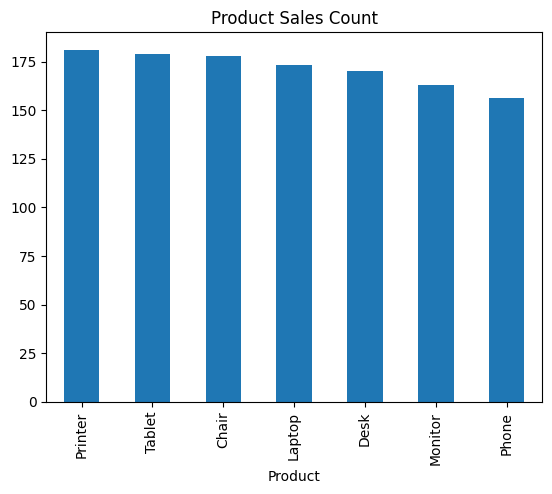

In [ ]:
import matplotlib.pyplot as plt

df["Product"].value_counts().plot(kind="bar")
plt.title("Product Sales Count")
plt.show()

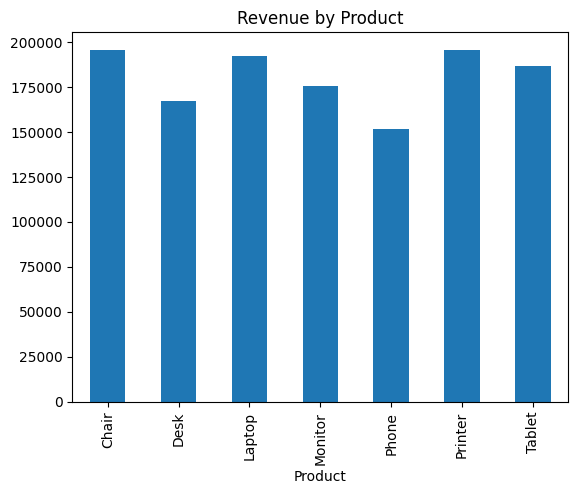

In [ ]:
df.groupby("Product")["TotalPrice"].sum().plot(kind="bar")
plt.title("Revenue by Product")
plt.show()

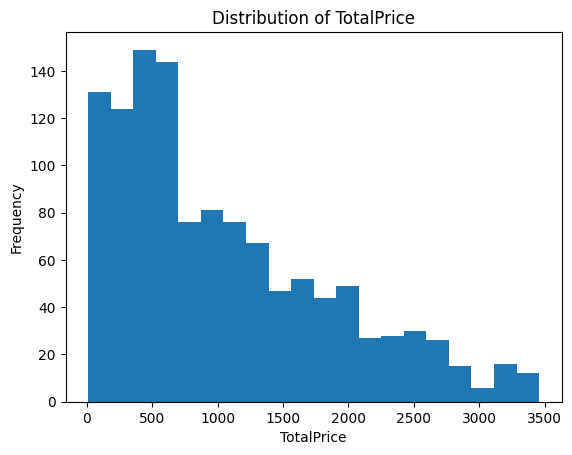

In [ ]:
import matplotlib.pyplot as plt

df["TotalPrice"].plot(kind="hist", bins=20)

plt.title("Distribution of TotalPrice")

plt.xlabel("TotalPrice")

plt.ylabel("Frequency")

plt.show()

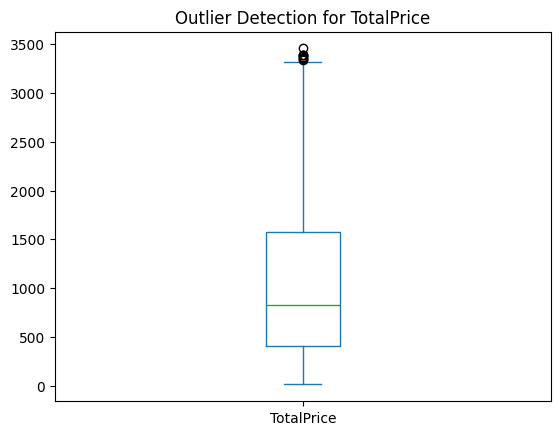

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("/content/Cleaned_Ecommerce_Dataset.xlsx")

df["TotalPrice"].plot(kind="box")

plt.title("Outlier Detection for TotalPrice")

plt.show()

In [ ]:
Q1 = df["TotalPrice"].quantile(0.25)

Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df["TotalPrice"] < (Q1 - 1.5 * IQR)) |
    (df["TotalPrice"] > (Q3 + 1.5 * IQR))
]

print(outliers)

        OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
107   ORD200107  2023-03-27     C16775  Printer         5     670.75   
326   ORD200326  2024-07-01     C65986   Laptop         5     670.48   
328   ORD200328  2023-02-28     C18404   Tablet         5     674.04   
469   ORD200469  2023-11-26     C13877    Chair         5     676.98   
632   ORD200632  2023-05-02     C67260   Laptop         5     678.16   
789   ORD200789  2023-08-17     C57276   Tablet         5     691.28   
1065  ORD201065  2023-10-30     C47778  Printer         5     666.80   
1122  ORD201122  2023-06-07     C38840  Monitor         5     678.19   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
107      848 Main St     Gift Card     Shipped    TRK34392124            8   
326      273 Main St     Gift Card    Returned    TRK98353867            5   
328      546 Main St        Online   Cancelled    TRK89401624            7   
469      893 Main St          Cash   Ca

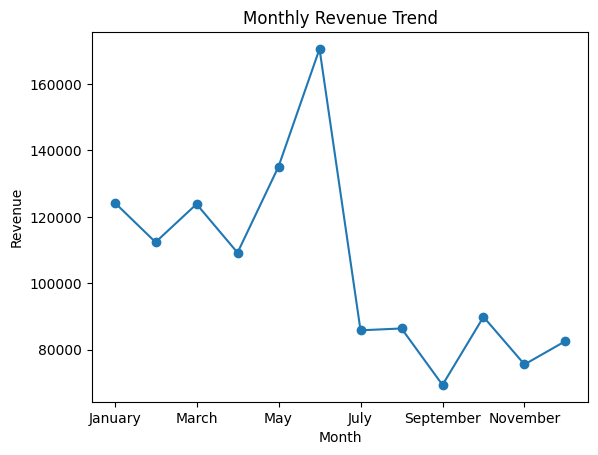

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = df.groupby(df["Date"].dt.month_name())["TotalPrice"].sum()

monthly_sales = monthly_sales.reindex([
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
])

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

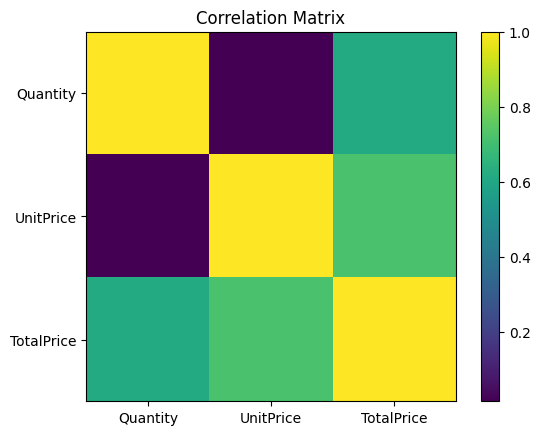

In [ ]:
plt.imshow(df[["Quantity", "UnitPrice", "TotalPrice"]].corr())

plt.colorbar()

plt.xticks(range(3), ["Quantity", "UnitPrice", "TotalPrice"])

plt.yticks(range(3), ["Quantity", "UnitPrice", "TotalPrice"])

plt.title("Correlation Matrix")

plt.show()

# Key Insights / Observations

* Certain products generated higher sales and revenue compared to others.
* Credit Card was one of the most frequently used payment methods.
* Monthly sales analysis showed variations in revenue across different months.
* Correlation analysis indicated that TotalPrice was strongly influenced by Quantity and UnitPrice.
* Outlier detection helped identify unusually high-value orders in the dataset.
